In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

In [14]:
df=pd.read_csv('/content/laptop_price_data.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


**Feature Extracting from df['ScreenResolution']**

In [18]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [19]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x.upper() else 0)

In [20]:
df['Touchscreen']=df['ScreenResolution'].apply(lambda x:1 if 'touchscreen' in x.lower() else 0)

In [21]:
df['Touchscreen'].value_counts()

,count
Touchscreen,
0,1111
1,192


In [22]:
new=df['ScreenResolution'].str.split('x',expand=True)

In [23]:
df['xRes']=new[0]
df['yRes']=new[1]

In [24]:
df['xRes']=df['xRes'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [25]:
df['xRes']=df['xRes'].astype('int')
df['yRes']=df['yRes'].astype('int')

In [26]:
df.drop(columns='ScreenResolution',axis=1,inplace=True)

In [27]:
df.dtypes

,0
Unnamed: 0,int64
Company,object
TypeName,object
Inches,float64
Cpu,object
Ram,object
Memory,object
Gpu,object
OpSys,object
Weight,object


**Feature Extracting from df['Cpu']**

In [28]:
def cpuBrandFinder(text):
  if 'Intel Core i5' in text:
    return 'Intel Core i5'
  elif 'Intel Core i7' in text:
    return 'Intel Core i7'
  elif 'Intel Core i3' in text:
    return 'Intel Core i3'
  else:
    return 'Others'

In [29]:
df['Cpu_brand']=df['Cpu'].apply(cpuBrandFinder)

In [30]:
df['Cpu_brand'].value_counts()

,count
Cpu_brand,
Intel Core i7,527
Intel Core i5,423
Others,217
Intel Core i3,136


In [31]:
df.drop(columns='Cpu',axis=1,inplace=True)

**Convert df['Ram'] to integer type**

In [32]:
df['Ram']=df['Ram'].str.replace('GB','').astype('int')

**Feature Extracting from df['Memory']**

In [33]:
df['Memory']=df['Memory'].str.replace('GB','').str.replace('TB','000').str.replace('.0','')

In [34]:
df['Memory'].value_counts()

,count
Memory,
256 SSD,412
1000 HDD,224
500 HDD,132
512 SSD,118
128 SSD + 1000 HDD,94
128 SSD,76
256 SSD + 1000 HDD,73
32 Flash Storage,38
2000 HDD,16


In [35]:
temp=df['Memory'].str.split('+',expand=True).rename(columns={0:'a',1:'b'})
temp

,a,b
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1298,128 SSD,None
1299,512 SSD,None
1300,64 Flash Storage,None
1301,1000 HDD,None


In [36]:
storageType=['SSD','HDD','Hybrid','Flash Storage']

for each in storageType:
  #temp[a]
  temp[each]=temp['a'].apply(lambda
                            x:re.findall((r'\d+'),x)[0] if each.lower() in x.lower()
                            else '0').astype(int)
  #temp[b]
  temp[each.lower()]=temp['b'].apply(lambda
                                  x:'0' if x is None
                                  else re.findall((r'\d+'),x)[0] if each.lower() in x.lower()
                                  else '0').astype('int')

  #combine temp[a] & temp[b]
  for t in temp.index:
    if temp[each.lower()][t]>temp[each][t]:
      temp[each][t]=temp[each.lower()][t]

  temp.drop(columns=each.lower(),axis=1,inplace=True)

/tmp/ipython-input-30829954.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp[each][t]=temp[each.lower()][t]
/tmp/ipython-input-30829954.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [37]:
temp.head()

,a,b,SSD,HDD,Hybrid,Flash Storage
0,128 SSD,None,128,0,0,0
1,128 Flash Storage,None,0,0,0,128
2,256 SSD,None,256,0,0,0
3,512 SSD,None,512,0,0,0
4,256 SSD,None,256,0,0,0


In [38]:
df['SSD']=temp['SSD']
df['HDD']=temp['HDD']
df['Hybrid']=temp['Hybrid']
df['Flash Storage']=temp['Flash Storage']
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,IPS,Touchscreen,xRes,yRes,Cpu_brand,SSD,HDD,Hybrid,Flash Storage
0,0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,1,0,2560,1600,Intel Core i5,128,0,0,0
1,1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,1440,900,Intel Core i5,0,0,0,128
2,2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,1920,1080,Intel Core i5,256,0,0,0
3,3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,1,0,2880,1800,Intel Core i7,512,0,0,0
4,4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,1,0,2560,1600,Intel Core i5,256,0,0,0


In [39]:
df.drop(columns='Memory',axis=1,inplace=True)
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,IPS,Touchscreen,xRes,yRes,Cpu_brand,SSD,HDD,Hybrid,Flash Storage
0,0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,1,0,2560,1600,Intel Core i5,128,0,0,0
1,1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,1440,900,Intel Core i5,0,0,0,128
2,2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,1920,1080,Intel Core i5,256,0,0,0
3,3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,1,0,2880,1800,Intel Core i7,512,0,0,0
4,4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,1,0,2560,1600,Intel Core i5,256,0,0,0


**Feature Extracting from df['Gpu']**

In [40]:
df['Gpu'].value_counts().head(5)

,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48


In [41]:
df['GpuBrand']=df['Gpu'].apply(lambda x:x.split(' ')[0])

In [42]:
df['GpuBrand'].value_counts()

,count
GpuBrand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [43]:
df['GpuBrand']=df['GpuBrand'].str.replace('ARM','AMD')

In [44]:
df['GpuBrand'].value_counts()

,count
GpuBrand,
Intel,722
Nvidia,400
AMD,181


In [45]:
df.drop(columns='Gpu',inplace=True)

**Feature Extracting from df['OpSys']**

In [46]:
def osFinder(text):
  if 'Windows' in text:
    return 'Windows'
  elif 'No OS' in text:
    return 'No OS'
  elif 'Linux' in text:
    return 'Linux'
  else:
    return 'Others'

In [47]:
df['OpSys']=df['OpSys'].apply(osFinder)

In [48]:
df['Weight']=df['Weight'].str.replace('kg','').astype('float')

In [49]:
df.drop(columns='Unnamed: 0',axis=1,inplace=True)

**Feature Extracting from df['Company']**

In [50]:
def companyFinder(text):
  if 'Lenovo' in text:
    return 'Lenovo'
  elif 'HP' in text:
    return 'HP'
  elif 'Dell' in text:
    return 'Dell'
  elif 'Asus' in text:
    return 'Asus'
  elif 'Acer' in text:
    return 'Acer'
  else:
    return 'Others'

In [51]:
df['Company']=df['Company'].apply(companyFinder)

In [52]:
def typeNameFinder(text):
  if 'Notebook' in text:
    return 'Notebook'
  elif 'Gaming' in text:
    return 'Gaming'
  elif 'Ultrabook' in text:
    return 'Ultrabook'
  else:
    return 'Others'

In [53]:
df['TypeName']=df['TypeName'].apply(typeNameFinder)

In [54]:
df.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,IPS,Touchscreen,xRes,yRes,Cpu_brand,SSD,HDD,Hybrid,Flash Storage,GpuBrand
0,Others,Ultrabook,13.3,8,Others,1.37,71378.6832,1,0,2560,1600,Intel Core i5,128,0,0,0,Intel
1,Others,Ultrabook,13.3,8,Others,1.34,47895.5232,0,0,1440,900,Intel Core i5,0,0,0,128,Intel
2,HP,Notebook,15.6,8,No OS,1.86,30636.0000,0,0,1920,1080,Intel Core i5,256,0,0,0,Intel
3,Others,Ultrabook,15.4,16,Others,1.83,135195.3360,1,0,2880,1800,Intel Core i7,512,0,0,0,AMD
4,Others,Ultrabook,13.3,8,Others,1.37,96095.8080,1,0,2560,1600,Intel Core i5,256,0,0,0,Intel


In [55]:
df.dtypes

,0
Company,object
TypeName,object
Inches,float64
Ram,int64
OpSys,object
Weight,float64
Price,float64
IPS,int64
Touchscreen,int64
xRes,int64


**Feature Selection**

In [56]:
df.select_dtypes(include=np.number).corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
IPS,0.252208
Touchscreen,0.191226
xRes,0.556529
yRes,0.552809
SSD,0.676202
HDD,-0.095672


Since the correlation of df['Hybrid'] is very small, we can drop this

In [57]:
df.drop('Hybrid',axis=1,inplace=True)

<Axes: >

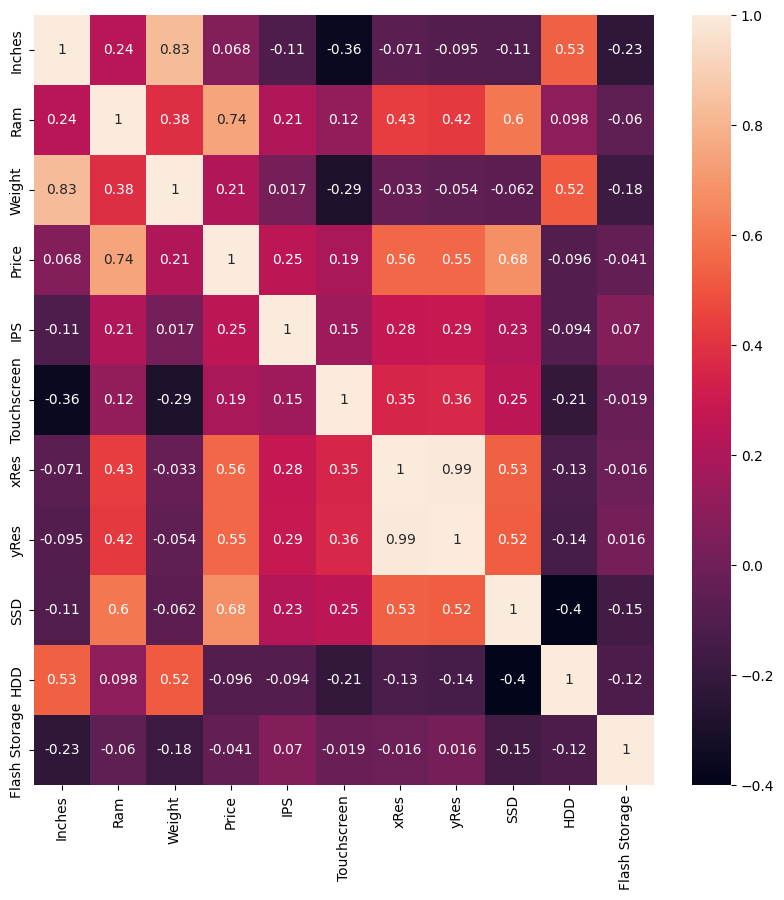

In [58]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

Since the correlation between df['Inches'] & df['Weight'], df['xRes'] & df['yRes'] is very high, we need to make a new feature which be correlated with df['price'].

In [59]:
df['weightPerInch']=df['Weight']/df['Inches']

In [60]:
df.select_dtypes(include=np.number).corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
IPS,0.252208
Touchscreen,0.191226
xRes,0.556529
yRes,0.552809
SSD,0.676202
HDD,-0.095672


In [61]:
df['xRes/yRes']=df['xRes']/df['yRes']

In [62]:
df.select_dtypes(include=np.number).corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
IPS,0.252208
Touchscreen,0.191226
xRes,0.556529
yRes,0.552809
SSD,0.676202
HDD,-0.095672


In [63]:
df['xyRes/inch']=df['xRes']*df['yRes']/(df['Inches'])

In [64]:
df.select_dtypes(include=np.number).corr()['Price']

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
IPS,0.252208
Touchscreen,0.191226
xRes,0.556529
yRes,0.552809
SSD,0.676202
HDD,-0.095672


In [65]:
df.drop(columns=['Inches','Weight','xRes','yRes','xRes/yRes'],axis=1,inplace=True)

Since df['weightPerInch'] and df['xyRes/inch'] are enough correlated with price, we take these. But, df['xRes/yRes'] is not correlated with df['Price'], so we don't take this.

<Axes: >

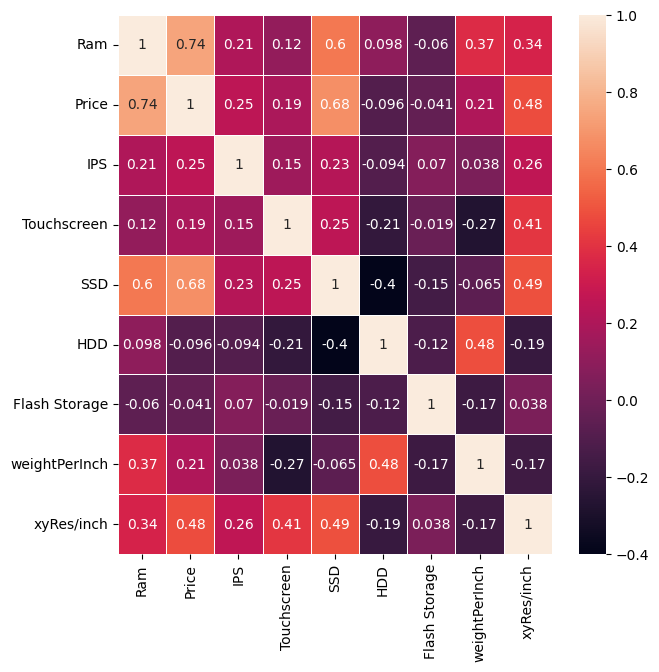

In [66]:
plt.figure(figsize=(7,7))
sns.heatmap(df.select_dtypes(np.number).corr(),annot=True,linewidths=0.5)

From above heatmap, we see that, ssd & ram has Moderate correlation. I want to fix this.

In [67]:
df['Ram*SSD']=df['SSD']*df['Ram']

<Axes: >

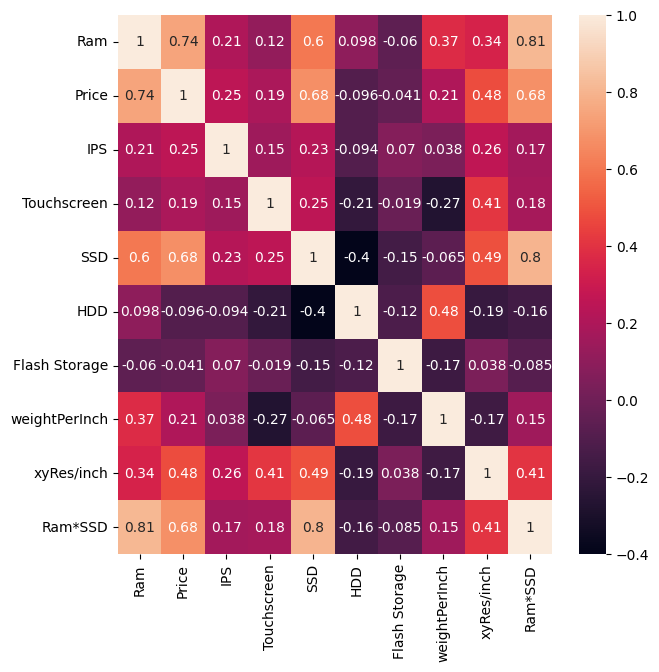

In [68]:
plt.figure(figsize=(7,7))
sns.heatmap(df.select_dtypes(np.number).corr(),annot=True)

The correlation of df['Ram*SSD'] with price is enough.

In [69]:
df.drop(columns=['Ram','SSD'],axis=1,inplace=True)

In [70]:
df.head()

,Company,TypeName,OpSys,Price,IPS,Touchscreen,Cpu_brand,HDD,Flash Storage,GpuBrand,weightPerInch,xyRes/inch,Ram*SSD
0,Others,Ultrabook,Others,71378.6832,1,0,Intel Core i5,0,0,Intel,0.103008,307969.924812,1024
1,Others,Ultrabook,Others,47895.5232,0,0,Intel Core i5,0,128,Intel,0.100752,97443.609023,0
2,HP,Notebook,No OS,30636.0000,0,0,Intel Core i5,0,0,Intel,0.119231,132923.076923,2048
3,Others,Ultrabook,Others,135195.3360,1,0,Intel Core i7,0,0,AMD,0.118831,336623.376623,8192
4,Others,Ultrabook,Others,96095.8080,1,0,Intel Core i5,0,0,Intel,0.103008,307969.924812,2048


<Axes: >

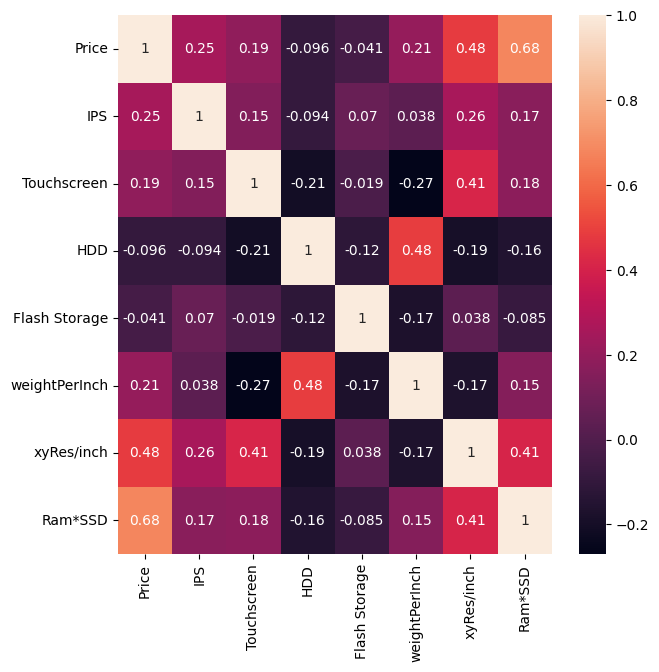

In [71]:
plt.figure(figsize=(7,7))
sns.heatmap(df.select_dtypes(np.number).corr(),annot=True)


**Encode Categorical Data**

In [72]:
encodedCat=pd.get_dummies(data=df[['Company','TypeName','OpSys','Cpu_brand','GpuBrand']].rename(
    columns={'TypeName':'Type','Cpu_brand':'CPU','GpuBrand':'GPU'}),
               drop_first=True,dtype=int)

In [73]:
df[encodedCat.columns]=encodedCat

In [74]:
df.dtypes

,0
Company,object
TypeName,object
OpSys,object
Price,float64
IPS,int64
Touchscreen,int64
Cpu_brand,object
HDD,int64
Flash Storage,int64
GpuBrand,object


In [75]:
df.drop(columns=['Company','TypeName','OpSys','Cpu_brand','GpuBrand'],axis=1,inplace=True)

In [76]:
df.dtypes

,0
Price,float64
IPS,int64
Touchscreen,int64
HDD,int64
Flash Storage,int64
weightPerInch,float64
xyRes/inch,float64
Ram*SSD,int64
Company_Asus,int64
Company_Dell,int64


In [77]:
df.corr()['Price']

,Price
Price,1.000000
IPS,0.252208
Touchscreen,0.191226
HDD,-0.095672
Flash Storage,-0.040511
weightPerInch,0.205512
xyRes/inch,0.479323
Ram*SSD,0.677732
Company_Asus,-0.010376
Company_Dell,0.048509


**Train Model**

In [78]:
mms=MinMaxScaler()
df[df.columns]=mms.fit_transform(df)

In [79]:
x=df.drop(columns='Price',axis=1)
y=df[['Price']]
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression().fit(xTrain,yTrain)
model.score(xTest,yTest)

0.7372117755093153

In [80]:
mean_squared_error(yTest,model.predict(xTest))

0.003802157335621024

In [82]:
model.predict(xTest).flatten().shape

(261,)

In [99]:
Lasso(alpha=0.001).fit(xTrain,yTrain).score(xTest,yTest)

0.6449649220965964

In [101]:
df.shape

(1303, 24)